# 次元数を変えた時の調査

In [1]:
import sys
import deepwalk
import numpy as np
import matplotlib.pyplot as plt
import random
import networkx as nx

In [4]:
def check_method(method):
    val = None
    if method == "kmedoids" or method =="Kmedoids":
        val = "kmedoids"
    elif method =="kmeans" or method == "Kmeans":
        val = "kmeans"
    elif method =="ward" or method =="Ward":
        val = "ward"
    else:
        sys.exit(f"methodの値が無効です method : {method}")
    return val

def check_data(data):
    if data == "football" or data == "polbooks" or data == "karateclub":
        pass
    else:

        sys.exit(f"変数dataの値が無効です data : {data}")


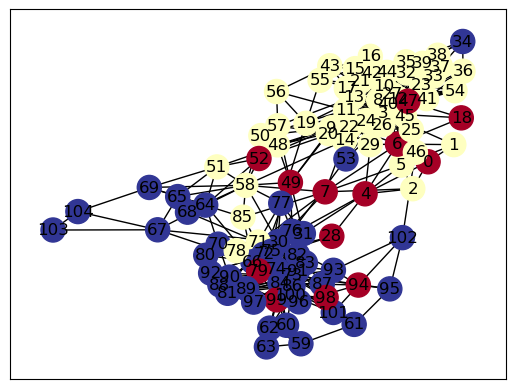

In [22]:
# 実行回数(埋め込み-クラスタリング-ARI)
TIME = 100

"""
data : 使用するデータ
football   : "football"
polbooks   : "polbooks"
karateclub : "karateclub"
"""
data = "polbooks"
check_data(data)

# インプットするファイル名
INPUT,TRUE_LABEL = deepwalk.generate_Graph(data)

# インプットするグラフが無向グラフかどうか(True:無向グラフ,　False:有向グラフ)
UNDIRECTED = True


# １ノードあたりの実行数
NUMBER_WALKS = 10

# 1ウォークあたりの長さ
WALK_LENGTH = 20

# skipgramので使われるウィンドウサイズ
WINDOW_SIZE = 4


# ランダムシード値
SEED = 0

# 埋め込み後の各ノードの次元数
REPRESENTATION_SIZE_LIST = range(1,31)

# 並列プロセス数
WORKERS = 1

# クラスタ数
N_CLUSTER = 3

# クラスタリング手法
"""
kmedoids : "kmedoids"
kmeans   : "kmeans"
"""
METHOD = check_method("ward")

# 結果を表示するかどうか
SHOW = False

raito_list = []


In [23]:
"""
    グラフ生成
    G = from_networkx(INPUT:networkxグラフインスタンス, 無効グラフかどうか:boolean)
    """
G = deepwalk.from_networkx(INPUT, True)
# ノード数出力
print("Number of nodes: {}".format(len(G.nodes())))

# ウォーク数算出(ノード数*1ノードあたりのウォーク数)と出力
num_walks = len(G.nodes()) * NUMBER_WALKS
print("Number of walks: {}".format(num_walks))

# データサイズ(ウォーク数*ウォークの長さ)の算出と出力
data_size = num_walks * WALK_LENGTH
print("Data size (walks*length): {}".format(data_size))


Number of nodes: 105
Number of walks: 1050
Data size (walks*length): 21000


In [24]:
mean_ari = []
for REPRESENTATION_SIZE in REPRESENTATION_SIZE_LIST:
    ARI_list, max_walks, min_walks, max_vec, min_vec, max_pred, min_pred = deepwalk.embed_ward(TIME, INPUT, UNDIRECTED, NUMBER_WALKS, WALK_LENGTH, REPRESENTATION_SIZE, WINDOW_SIZE, WORKERS, N_CLUSTER, METHOD, TRUE_LABEL,SHOW)
    mean_ari.append(np.mean(ARI_list))
    

    

最大ARI([25]回目実行) : 0.527347801215046
最小ARI([65]回目実行) : 0.2904792440889751
平均ARI : 0.43319565303643004
標準偏差：0.0631340961771532
最大ARI([11, 86, 99]回目実行) : 0.543322819333112
最小ARI([35]回目実行) : 0.29299822862827885
平均ARI : 0.4517036616339204
標準偏差：0.07002983498057651
最大ARI([47, 100]回目実行) : 0.5459300182297796
最小ARI([93]回目実行) : 0.30865628225986097
平均ARI : 0.48477069324002126
標準偏差：0.047614568388405186
最大ARI([81]回目実行) : 0.5369077354155349
最小ARI([24]回目実行) : 0.3936124641038252
平均ARI : 0.501515958223322
標準偏差：0.021032845271186238
最大ARI([22]回目実行) : 0.5272245515956208
最小ARI([89]回目実行) : 0.3804329831319119
平均ARI : 0.49767964922679475
標準偏差：0.02288069354313421
最大ARI([86]回目実行) : 0.5272245515956208
最小ARI([91]回目実行) : 0.44256713371608214
平均ARI : 0.5024449189180392
標準偏差：0.014675673378169544
最大ARI([64]回目実行) : 0.5369077354155349
最小ARI([59]回目実行) : 0.3963187922135021
平均ARI : 0.4997318832896843
標準偏差：0.022788987773070007
最大ARI([9]回目実行) : 0.5308557008488185
最小ARI([18]回目実行) : 0.4413902585273475
平均ARI : 0.4966043228068644

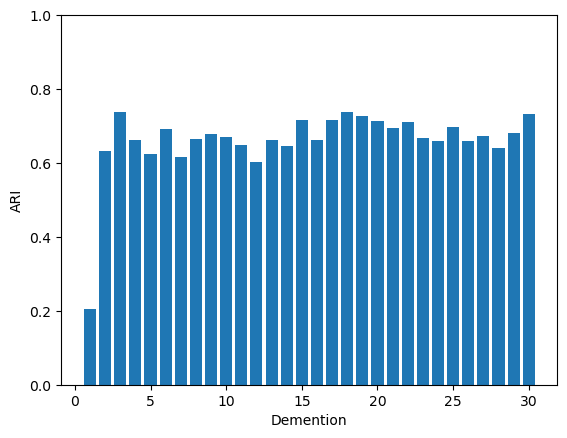

In [20]:
# mean_ariを棒グラフで描画 Y軸の範囲を0.0~1.0に設定
plt.bar(REPRESENTATION_SIZE_LIST, mean_ari)
plt.ylim(0.0, 1.0)
plt.xlabel("Demention")
plt.ylabel("ARI")
plt.show()
